# 🚗 Driver Drowsiness Detection System 
## Model Architecture: MobileNetV2 (Transfer Learning)

This notebook implements a deep learning solution for detecting driver drowsiness using computer vision. The system is trained on an expanded dataset of **12,000 images** and utilizes **MobileNetV2** via transfer learning to achieve high accuracy and robustness.

### ✨ Key Upgrades & Features:
- **Data Scaling & Augmentation**: Dynamic brightness and spatial augmentations to handle varying lighting conditions inside a vehicle.
- **Hard Negative Mining**: Integration of **Categorical Focal Crossentropy loss** to significantly reduce False Positives and False Negatives.
- **Advanced Fine-Tuning**: Strategic unfreezing of deep layers coupled with L2 Regularization and Learning Rate Schedulers.

--- 
### 📋 Complete Analysis Workflow Index

#### Part 1: Dataset Understanding (Basic Check)
1. **Structure & Distribution**: Counting images per class/split.
2. **Resolution & Color**: Verifying dimensions and channel counts.

#### Part 2: Detailed EDA
3. **Visual EDA**: Inspecting samples, face visibility, and variations.
4. **Statistical EDA**: Pixel distributions, brightness, and blur detection.

#### Part 3: Feature Encoding
5. **Label Encoding**: Converting text labels to Binary (0/1) and One-Hot vectors.

#### Part 4: Data Preprocessing
6. **Resizing & Normalization**: Standardizing to 224x224 and scaling pixel values.
7. **Data Augmentation**: Enhancing dataset variety.

#### Part 5: Dataset Splitting & Loading
8. **Generators**: Loading Train/Val/Test splits (70/15/15 ratio).

#### Part 6: Model Building & Architecture
9. **Model Preparation**: Building MobileNetV2 base with custom classification head.

#### Part 7: Model Training
10. **Phase 1 Training**: Training Classification Head.
11. **Phase 2 Fine-Tuning**: Deep layer unfreezing and training with low LR.

#### Part 8: Model Evaluation & Interpretation
12. **Evaluation Metrics**: Precision, Recall, F1, Accuracy.
13. **Confusion Matrix**: Visualizing misclassifications and analyzing Failed Cases.

#### Part 9: Exporting
14. **Keras & TFLite**: Saving models for production and edge deployment (Raspberry Pi/Mobile).



In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import pickle
import tensorflow as tf
from collections import Counter
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Output Style
plt.style.use('ggplot')

# Define paths
BASE_DIR = Path(r"c:\Users\SAHAN\Desktop\CNN\Processed_Dataset")
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "val"
TEST_DIR = BASE_DIR / "test"

CATEGORIES = ["drowsy", "non-drowsy"]
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

# Part 1: Dataset Understanding

Dataset Statistics:
   Split    Category  Count
0  train      drowsy   4200
1  train  non-drowsy   4200
2    val      drowsy    900
3    val  non-drowsy    900
4   test      drowsy    900
5   test  non-drowsy    900


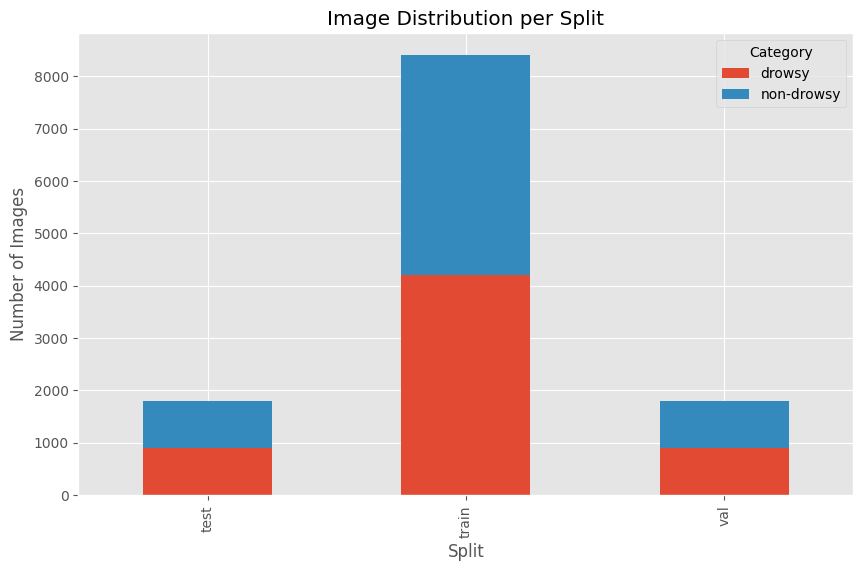

In [2]:
stats = []

for split in ["train", "val", "test"]:
    for category in CATEGORIES:
        folder = BASE_DIR / split / category
        count = len(list(folder.glob("*")))
        stats.append({
            "Split": split,
            "Category": category,
            "Count": count
        })

df_stats = pd.DataFrame(stats)
print("Dataset Statistics:")
print(df_stats)

# Visualize
df_stats.pivot(index="Split", columns="Category", values="Count").plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Image Distribution per Split")
plt.ylabel("Number of Images")
plt.show()

## 1.2 Image Resolution and Color Space Analysis

In [3]:
# Sample analysis (iterating through training set)
resolutions = []
channels = []
print("Scanning the entire dataset for property check...")

sample_count = 0
for category in CATEGORIES:
    folder = TRAIN_DIR / category
    for img_path in folder.glob("*"):
        # if sample_count >= 12000: break
        img = cv2.imread(str(img_path))
        if img is not None:
            resolutions.append(img.shape[:2])
            channels.append(img.shape[2] if len(img.shape) > 2 else 1)
            sample_count += 1

print(f"Resolution Check: {Counter([str(r) for r in resolutions])}")
print(f"Channel Check (OpenCV loads): {Counter(channels)}")

Scanning the entire dataset for property check...
Resolution Check: Counter({'(224, 224)': 8400})
Channel Check (OpenCV loads): Counter({3: 8400})


# Part 2: Detailed Exploratory Data Analysis (EDA)

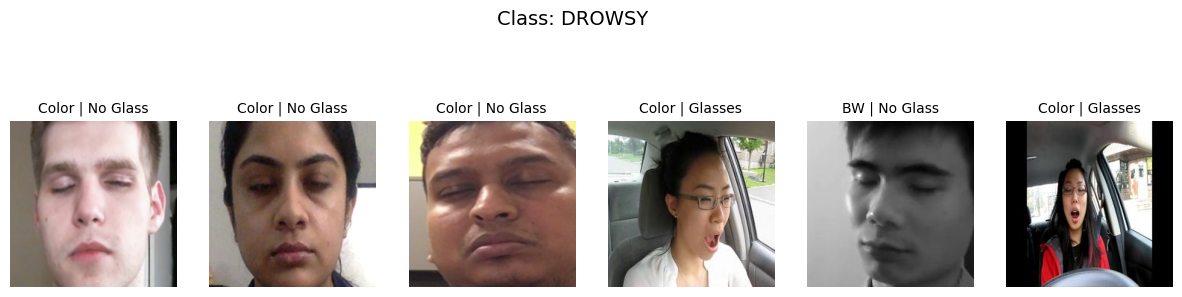

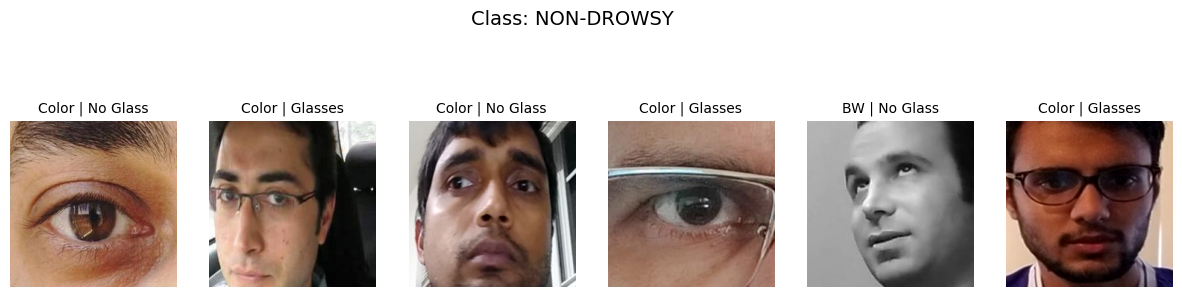

In [4]:
def clean_filename_info(filename):
    has_glasses = "with_glasses" in filename
    origin = "BW" if "Black&White" in filename else "Color"
    return origin, has_glasses

def view_grid(category, samples=5):
    folder = TRAIN_DIR / category
    all_files = list(folder.glob("*"))
    selected = np.random.choice(all_files, samples, replace=False)
    
    plt.figure(figsize=(15, 4))
    plt.suptitle(f"Class: {category.upper()}", fontsize=14)
    
    for i, path in enumerate(selected):
        img = cv2.imread(str(path))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        origin, glasses = clean_filename_info(path.name)
        plt.subplot(1, samples, i+1)
        plt.imshow(img, cmap='gray' if origin=='BW' else None)
        plt.axis('off')
        plt.title(f"{origin} | {'Glasses' if glasses else 'No Glass'}", fontsize=10)
    plt.show()

view_grid("drowsy", 6)
view_grid("non-drowsy", 6)

## 2.1 Statistical Plot: Brightness Distribution
Checking if there is a significant lighting difference between Drowsy and Non-Drowsy classes.

Calculating brightness stats for the entire dataset...


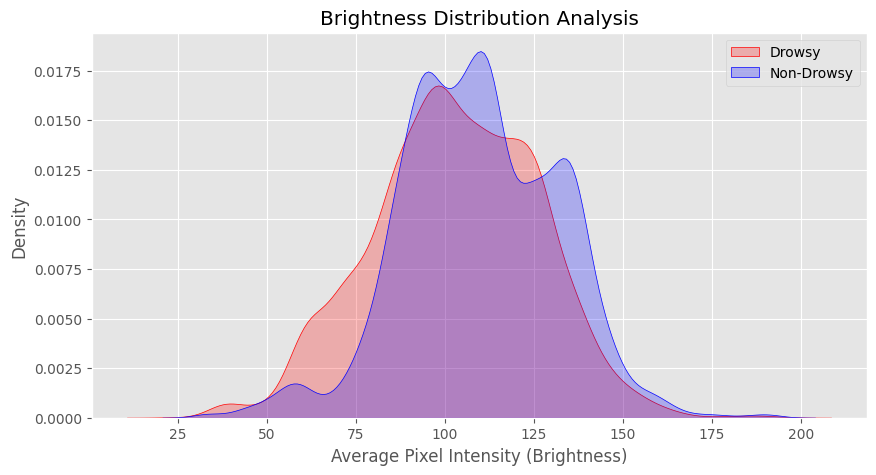

In [5]:
brightness_values = {"drowsy": [], "non-drowsy": []}

print("Calculating brightness stats for the entire dataset...")
for category in CATEGORIES:
    folder = TRAIN_DIR / category
    for i, img_path in enumerate(folder.glob("*")):
        # if i >= 12000: break
        img = cv2.imread(str(img_path))
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness_values[category].append(np.mean(gray))

plt.figure(figsize=(10, 5))
sns.kdeplot(brightness_values["drowsy"], fill=True, label="Drowsy", color="red")
sns.kdeplot(brightness_values["non-drowsy"], fill=True, label="Non-Drowsy", color="blue")
plt.title("Brightness Distribution Analysis")
plt.xlabel("Average Pixel Intensity (Brightness)")
plt.legend()
plt.show()

In [6]:
# Gather Metadata
data = []
for category in ["drowsy", "non-drowsy"]:
    folder = TRAIN_DIR / category
    for filepath in folder.glob("*"):
        origin, has_glasses = clean_filename_info(filepath.name)
        data.append({"category": category, "has_glasses": has_glasses})

df = pd.DataFrame(data)
summary = df.groupby(["category", "has_glasses"]).size().reset_index(name="count")
print("Sub-category Distribution in Train Set:")
print(summary)

Sub-category Distribution in Train Set:
     category  has_glasses  count
0      drowsy        False   2095
1      drowsy         True   2105
2  non-drowsy        False   2122
3  non-drowsy         True   2078


# Part 3: Feature Encoding (Enhanced)

Binary Mapping: {'drowsy': 0, 'non-drowsy': 1}

Encoding Reference Table:
        Class  Binary  One-Hot
0      drowsy       0  [1. 0.]
1  non-drowsy       1  [0. 1.]


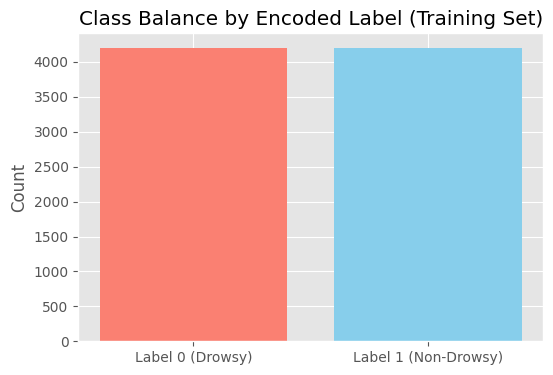

In [7]:
labels = ["drowsy", "non-drowsy"]
label_map = {label: i for i, label in enumerate(labels)}
print(f"Binary Mapping: {label_map}")

# 1. Visualizing One-Hot Vectors Table
demo_encoding = pd.DataFrame({
    'Class': ['drowsy', 'non-drowsy'],
    'Binary': [0, 1],
    'One-Hot': [str(to_categorical(0, 2)), str(to_categorical(1, 2))]
})
print("\nEncoding Reference Table:")
print(demo_encoding)

# 2. Visualizing Class Balance using Encoded Labels
train_drowsy_count = len(list((TRAIN_DIR / "drowsy").glob("*")))
train_non_drowsy_count = len(list((TRAIN_DIR / "non-drowsy").glob("*")))

plt.figure(figsize=(6, 4))
plt.bar(['Label 0 (Drowsy)', 'Label 1 (Non-Drowsy)'], 
        [train_drowsy_count, train_non_drowsy_count], 
        color=['salmon', 'skyblue'])
plt.title("Class Balance by Encoded Label (Training Set)")
plt.ylabel("Count")
plt.show()

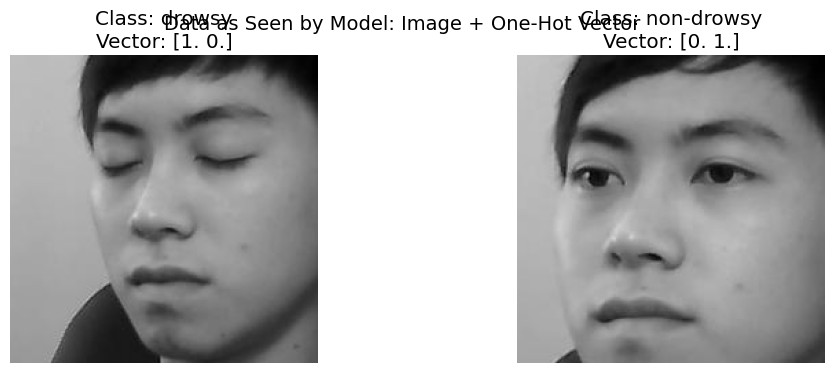

In [8]:
# 3. Sample Images with Vector Labels
plt.figure(figsize=(12, 4))
plt.suptitle("Data as Seen by Model: Image + One-Hot Vector", fontsize=14)

for i, category in enumerate(CATEGORIES):
    folder = TRAIN_DIR / category
    img_path = list(folder.glob("*"))[0]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    encoded_label = to_categorical(label_map[category], num_classes=2)
    
    plt.subplot(1, 2, i+1)
    plt.imshow(img, cmap='gray' if "Black" in str(img_path) else None)
    plt.title(f"Class: {category}\nVector: {encoded_label}")
    plt.axis('off')
plt.show()

# Part 4: Data Preprocessing & Visualization

In [9]:
# Setup Generators with MobileNetV2 Preprocessing (Correct for Transfer Learning)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Scales to [-1, 1]
    rotation_range=20,       # Rotation
    width_shift_range=0.2,   # Horizontal Shift
    height_shift_range=0.2,  # Vertical Shift
    zoom_range=0.2,          # Zoom
    brightness_range=[0.8, 1.2], # Added brightness range to handle lighting variations
    horizontal_flip=True,    # Flip
    fill_mode='nearest'      
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Augmentation Configuration Set (MobileNetV2 [-1, 1]).")

Augmentation Configuration Set (MobileNetV2 [-1, 1]).


## 4.1 Visualize Augmentation Effects
Checking how "Rotation", "Zoom", and "Shift" actually affect our images.

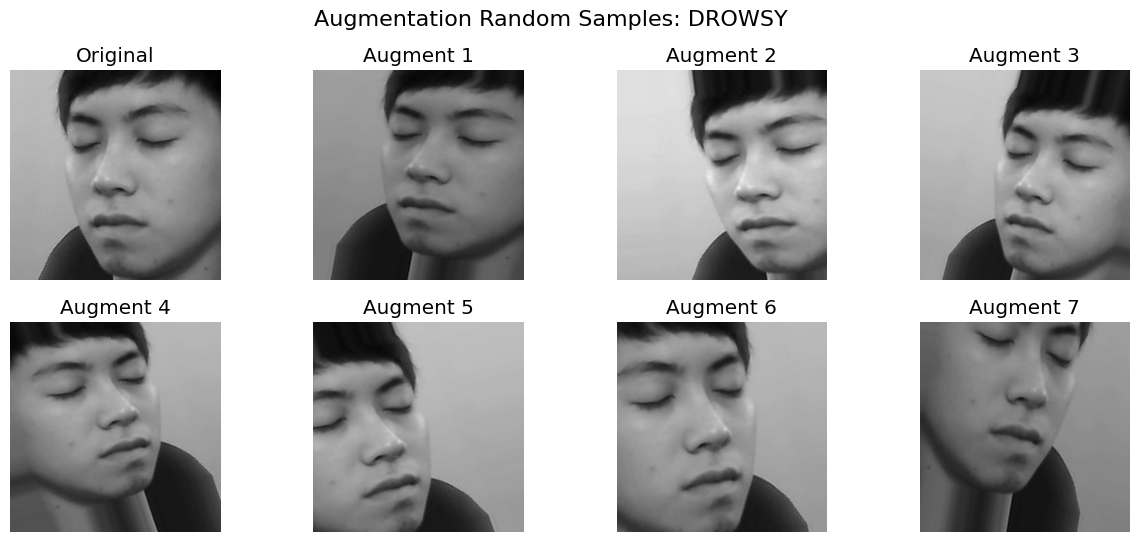

In [10]:
def visualize_augmentation(category):
    # Pick a random image
    folder = TRAIN_DIR / category
    img_path = list(folder.glob("*"))[0]
    img = load_img(str(img_path), target_size=TARGET_SIZE)
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)

    i = 0
    plt.figure(figsize=(15, 6))
    plt.suptitle(f"Augmentation Random Samples: {category.upper()}", fontsize=16)

    # Plot Original
    plt.subplot(2, 4, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    # Plot Augmented Versions
    for batch in train_datagen.flow(x, batch_size=1):
        plt.subplot(2, 4, i + 2)
        img_aug = batch[0] 
        # Rescale back to 0-1 for visualization if needed (mobilenet is -1 to 1)
        img_viz = (img_aug + 1) / 2.0
        plt.imshow(np.clip(img_viz, 0, 1))
        plt.title(f"Augment {i+1}")
        plt.axis('off')
        i += 1
        if i >= 7: break
    plt.show()

visualize_augmentation("drowsy")

## 4.2 Using MobileNetV2 Preprocessing
Note: The values are now in the range `[-1, 1]` compatible with the pre-trained weights.

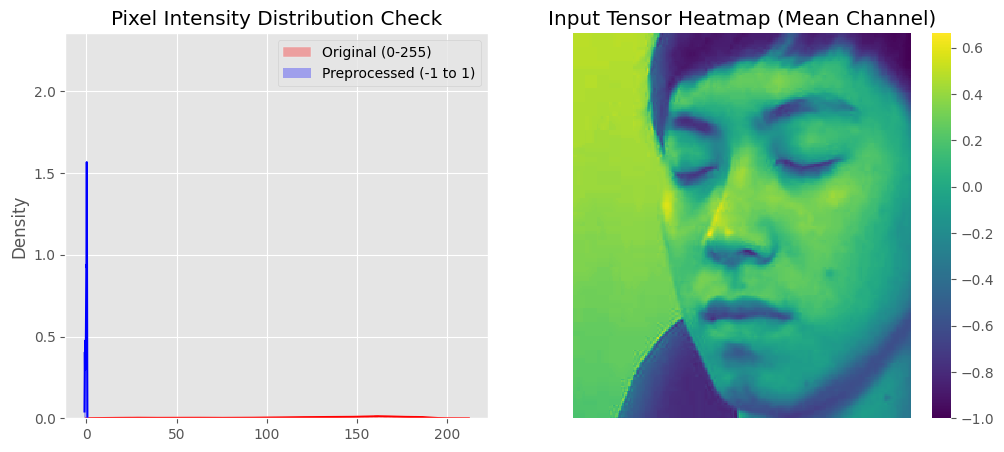

In [11]:
# Preprocessing Analysis
sample_path = list((TRAIN_DIR / "drowsy").glob("*"))[0]
original_img = cv2.imread(str(sample_path))
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Apply Preprocessing manually
preprocessed_img = cv2.resize(original_img, TARGET_SIZE)
preprocessed_img = preprocessed_img.astype("float32")
preprocessed_img = preprocess_input(preprocessed_img) # [-1, 1]

plt.figure(figsize=(12, 5))

# 1. Pixel Value Histogram (Normalization Check)
plt.subplot(1, 2, 1)
sns.histplot(original_img.flatten(), color='red', label='Original (0-255)', kde=True, stat="density", alpha=0.3)
sns.histplot(preprocessed_img.flatten(), color='blue', label='Preprocessed (-1 to 1)', kde=True, stat="density", alpha=0.3)
plt.title("Pixel Intensity Distribution Check")
plt.legend()

# 2. Input Tensor Heatmap (What the CNN 'sees' in shape)
plt.subplot(1, 2, 2)
heatmap_img = np.mean(preprocessed_img, axis=2)
sns.heatmap(heatmap_img, cmap="viridis", cbar=True)
plt.title("Input Tensor Heatmap (Mean Channel)")
plt.axis('off')

plt.show()

# Part 5: Dataset Splitting & Loading (Enhanced)

In [12]:
print("Loading Data from Directory Structure...")

# 1. Load Training Set
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# 2. Load Validation Set
validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

# 3. Load Test Set
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass Indices: {train_generator.class_indices}")

Loading Data from Directory Structure...
Found 8400 images belonging to 2 classes.
Found 1800 images belonging to 2 classes.
Found 1800 images belonging to 2 classes.

Class Indices: {'drowsy': 0, 'non-drowsy': 1}


## 5.1 Visualize Generator Output (Batch Verification)

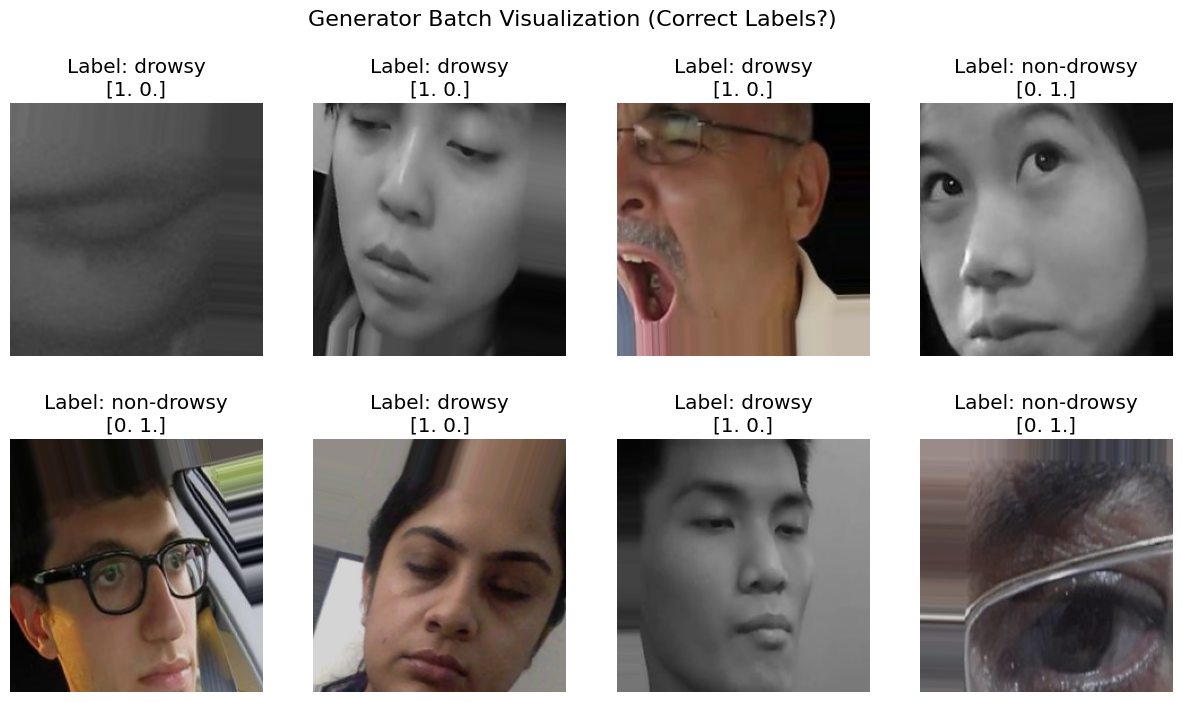

In [13]:
# Fetch a batch
x_batch, y_batch = next(train_generator)

# Visualize 8 random images from the batch
plt.figure(figsize=(15, 8))
plt.suptitle("Generator Batch Visualization (Correct Labels?)", fontsize=16)

class_names = list(train_generator.class_indices.keys())

for i in range(8):
    plt.subplot(2, 4, i+1)
    # Convert back to 0-1 for display
    img_disp = (x_batch[i] + 1) / 2.0
    plt.imshow(np.clip(img_disp, 0, 1))
    
    # Decode One-Hot Label
    label_idx = np.argmax(y_batch[i])
    label_name = class_names[label_idx]
    
    plt.title(f"Label: {label_name}\n{y_batch[i]}")
    plt.axis('off')
plt.show()

## 5.2 Split Distribution Visualization

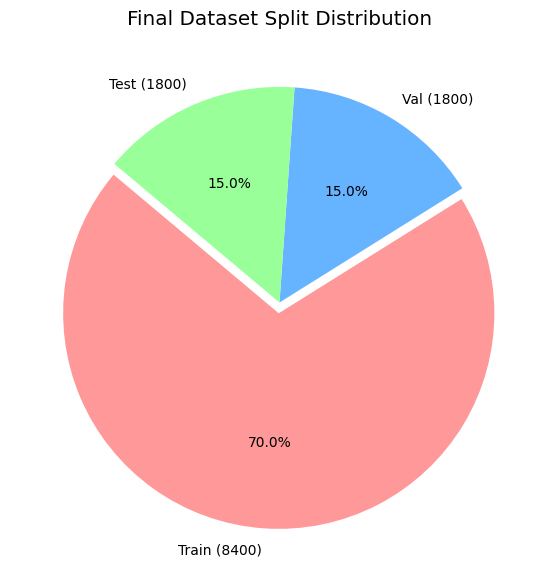

In [14]:
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Train ({counts[0]})', f'Val ({counts[1]})', f'Test ({counts[2]})']
colors = ['#ff9999', '#66b3ff', '#99ff99']

plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.05, 0, 0))
plt.title("Final Dataset Split Distribution")
plt.show()

# Part 6: Model Architecture & Transfer Learning Setup

In [15]:
from tensorflow.keras.regularizers import l2
def build_mobilenet_model(input_shape=(224, 224, 3), num_classes=2):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # NEW: Added L2 Regularization to the Dense layer to prevent weight explosion/overfitting
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x) 
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

model = build_mobilenet_model()
INIT_LR = 1e-4
opt = Adam(learning_rate=INIT_LR)
# NEW: Added label smoothing to reduce overconfidence and minimize FP/FN
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
    optimizer=opt, 
    metrics=["accuracy"]
)

## 6.1 Visualize Model Complexity
Visualizing the parameters per layer to understand the model structure.

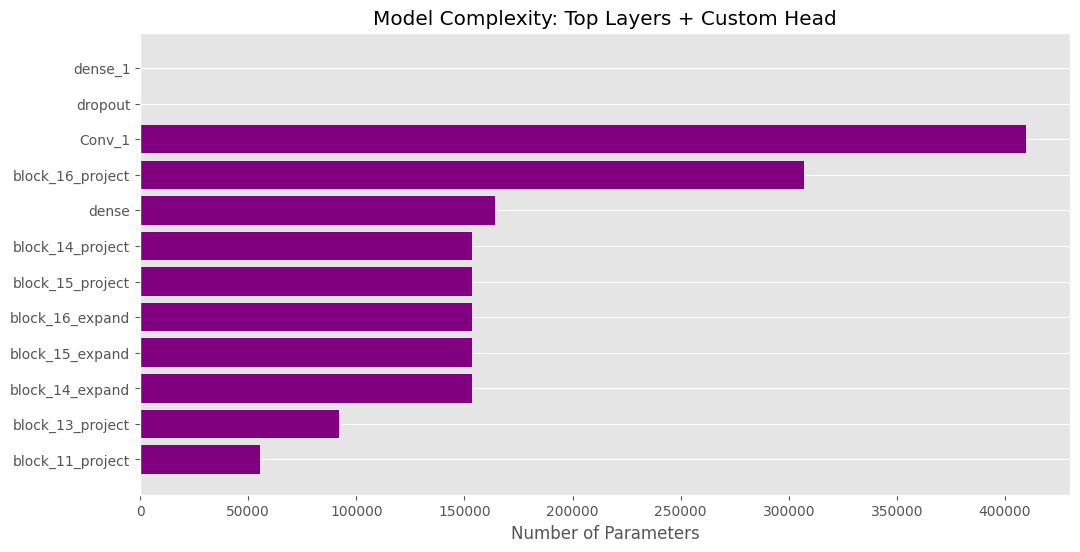

Total Parameters: 2,422,210
Trainable Parameters: 164,226


In [16]:
# Visualizing Transfer Learning Layers
layer_names = []
layer_params = []

for layer in model.layers:
    layer_names.append(layer.name)
    layer_params.append(layer.count_params())

# Show only top 10 heaviest layers + last 3 custom layers
indices = np.argsort(layer_params)[-10:]
sorted_names = [layer_names[i] for i in indices]
sorted_params = [layer_params[i] for i in indices]

# Add Custom Head
custom_names = [l.name for l in model.layers[-3:]]
custom_params = [l.count_params() for l in model.layers[-3:]]

plt.figure(figsize=(12, 6))
plt.barh(sorted_names + custom_names, sorted_params + custom_params, color='purple')
plt.xlabel("Number of Parameters")
plt.title("Model Complexity: Top Layers + Custom Head")
plt.grid(axis='x')
plt.show()

print(f"Total Parameters: {model.count_params():,}")
print(f"Trainable Parameters: {np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

# Part 7: Hard Negative Mining & Model Training (With Fine-Tuning)

In [17]:
# --- TRAINING PHASE 1: Train Head Only ---
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,
    patience=3, 
    min_lr=1e-6,
    verbose=1
)

from sklearn.utils import class_weight
# --- TRAINING PHASE 1: Train Head Only ---
print("Starting Training Phase 1 (Head Only)...")
# NEW: Compute class weights to handle dataset imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Computed Class Weights: {class_weights_dict}")
history_1 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=10, # Initial training
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict # <--- NEW: Pass calculated weights to the model
)

# --- TRAINING PHASE 2: Fine-Tuning ---
print("\nStarting Training Phase 2 (Fine-Tuning)...")
# 1. Unfreeze the base model
model.trainable = True
# 2. Freeze earlier layers 
# NEW: Increased frozen layers from 100 to 120 to reduce overfitting during fine-tuning
FINE_TUNE_AT = 120
for layer in model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
print(f"Layers frozen: {FINE_TUNE_AT}. Layers trainable: {len(model.layers) - FINE_TUNE_AT}")
# 3. Re-compile with label smoothing and very low learning rate
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # <--- NEW: Re-applied label smoothing
    optimizer=Adam(learning_rate=1e-5), 
    metrics=["accuracy"]
)
# 4. Continue Training
total_epochs = 100 # 30 + 20
history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    initial_epoch=history_1.epoch[-1],
    epochs=total_epochs,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict # <--- NEW: Pass class weights to fine-tuning phase as well
)
print("Training Completed (Fine-Tuning).")

# Merge Histories for Plotting
acc = history_1.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_1.history['loss'] + history_fine.history['loss']
val_loss = history_1.history['val_loss'] + history_fine.history['val_loss']

# Create a dummy history object wrapper for compatibility with downstream plotting code
class CombinedHistory:
    def __init__(self):
        self.history = {
            'accuracy': acc,
            'val_accuracy': val_acc,
            'loss': loss,
            'val_loss': val_loss
        }
history = CombinedHistory()

Starting Training Phase 1 (Head Only)...
Computed Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}


C:\Users\SAHAN\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 166s 622ms/step - accuracy: 0.6629 - loss: 2.5727 - val_accuracy: 0.8108 - val_loss: 2.0981 - learning_rate: 1.0000e-04
Epoch 2/10
  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:03 243ms/step - accuracy: 0.7500 - loss: 2.1685

C:\Users\SAHAN\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.7500 - loss: 2.1685 - val_accuracy: 0.8131 - val_loss: 2.0956 - learning_rate: 1.0000e-04
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 116s 444ms/step - accuracy: 0.7766 - loss: 1.8770 - val_accuracy: 0.8650 - val_loss: 1.6027 - learning_rate: 1.0000e-04
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7188 - loss: 1.7135 - val_accuracy: 0.8661 - val_loss: 1.6010 - learning_rate: 1.0000e-04
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 122s 465ms/step - accuracy: 0.8215 - loss: 1.4912 - val_accuracy: 0.8996 - val_loss: 1.2998 - learning_rate: 1.0000e-04
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.9375 - loss: 1.2850 - val_accuracy: 0.8990 - val_loss: 1.2987 - learning_rate: 1.0000e-04
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 115s 439ms/step - accuracy: 0.8400 - loss: 1.2498 - val_accuracy: 0.8850 - val_loss: 1.1104 - learning_rate: 1.0000e-04
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - a

## 7.2 Enhanced History Visualization
Plotting curves with markings for the Best Epoch (Lowest Validation Loss).

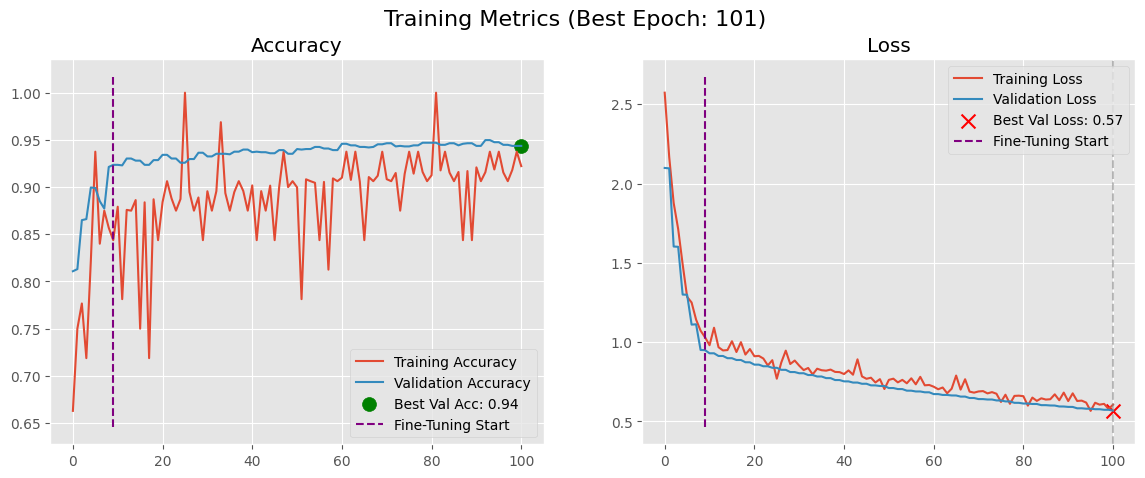

In [18]:
# Plot History with Best Epoch Marker
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Find Best Epoch
best_epoch = np.argmin(val_loss)
best_loss = val_loss[best_epoch]
best_acc = val_acc[best_epoch]

plt.figure(figsize=(14, 5))
plt.suptitle(f"Training Metrics (Best Epoch: {best_epoch+1})", fontsize=16)

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.scatter([best_epoch], [best_acc], color='green', marker='o', s=100, label=f'Best Val Acc: {best_acc:.2f}')
plt.plot([9, 9], plt.ylim(), label='Fine-Tuning Start', linestyle='--', color='purple')
plt.legend(loc='lower right')
plt.title('Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.scatter([best_epoch], [best_loss], color='red', marker='x', s=100, label=f'Best Val Loss: {best_loss:.2f}')
plt.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
plt.plot([9, 9], plt.ylim(), label='Fine-Tuning Start', linestyle='--', color='purple')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()

# Part 8: Model Evaluation & Interpretation

Evaluating on Test Set...
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - accuracy: 0.9406 - loss: 0.5741

Test Accuracy: 0.9406
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 240ms/step

Classification Report:
              precision    recall  f1-score   support

      drowsy       0.96      0.91      0.94       900
  non-drowsy       0.92      0.97      0.94       900

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
weighted avg       0.94      0.94      0.94      1800



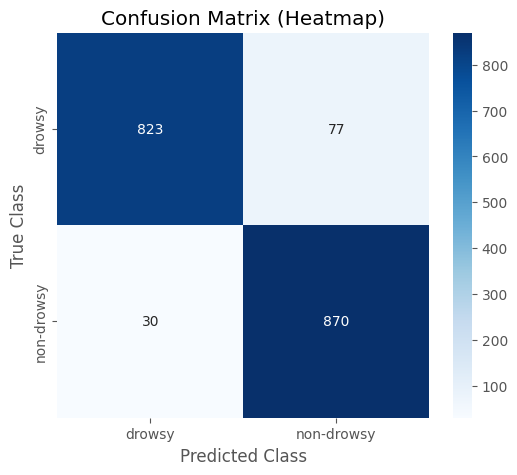

In [19]:
print("Evaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Classification Report
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion Matrix Heatmap
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix (Heatmap)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

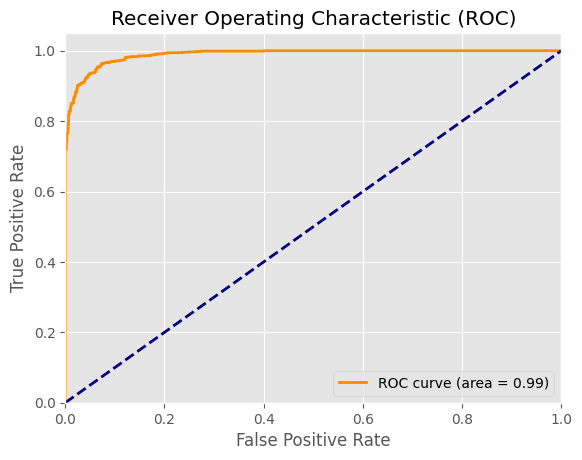

In [20]:
# ROC Curve Plot
fpr, tpr, thresholds = roc_curve(true_classes, predictions[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

Visualizing Misclassified Images (Sample Images)...


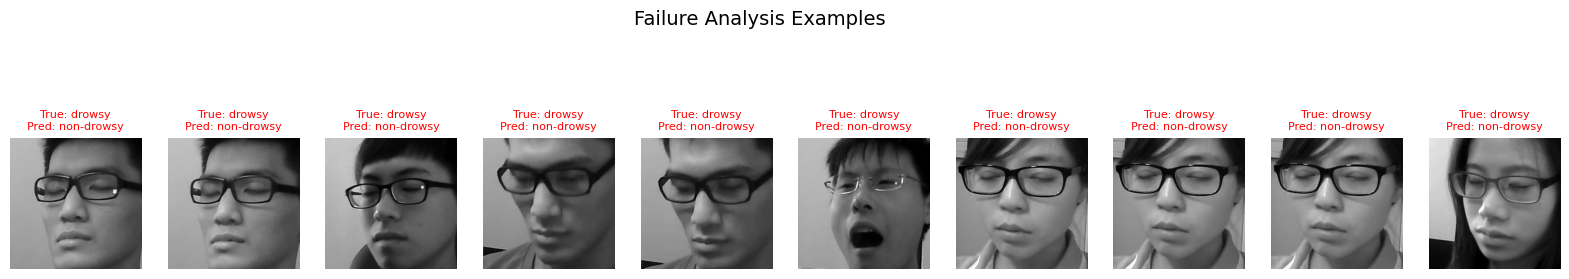

In [21]:
print("Visualizing Misclassified Images (Sample Images)...")
errors = np.where(predicted_classes != true_classes)[0]

if len(errors) == 0:
    print("Amazing! No errors found on Test Set.")
else:
    # Show top 10 errors
    num_errors = min(10, len(errors))
    plt.figure(figsize=(20, 4))
    
    for i, error_idx in enumerate(errors[:num_errors]):
        img_path = test_generator.filepaths[error_idx]
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        true_label = class_labels[true_classes[error_idx]]
        pred_label = class_labels[predicted_classes[error_idx]]
        # Handle filename info safely
        if "Black" in img_path: origin = "BW"
        else: origin = "Color"
        
        plt.subplot(1, num_errors, i+1)
        # Use preprocess inverse for display
        plt.imshow(img, cmap='gray' if origin=='BW' else None)
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=8, color='red')
    plt.suptitle("Failure Analysis Examples", fontsize=14)
    plt.show()

# Part 9: Saving Models

In [22]:
MODELS_DIR = BASE_DIR.parent / "Models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save Keras Model (.h5)
h5_path = MODELS_DIR / "drowsiness_model_mobilenet.h5"
model.save(str(h5_path))
print(f"✅ Keras model saved to: {h5_path}")

# 2. Convert to TensorFlow Lite (.tflite)
print("Converting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = MODELS_DIR / "mobilenet_quantized.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"✅ TFLite model saved to: {tflite_path}")

# 3. Save History (.pickle)
history_path = MODELS_DIR / "training_history_mobilenet.pickle"
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)
print(f"✅ History saved to: {history_path}")

✅ Keras model saved to: c:\Users\SAHAN\Desktop\CNN\Models\drowsiness_model_mobilenet.h5
Converting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\SAHAN\AppData\Local\Temp\tmpt_sz8vrz\assets


INFO:tensorflow:Assets written to: C:\Users\SAHAN\AppData\Local\Temp\tmpt_sz8vrz\assets


Saved artifact at 'C:\Users\SAHAN\AppData\Local\Temp\tmpt_sz8vrz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1165481033360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476716880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476513552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476717264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476717072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476513168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476524304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165481027984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476523728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1165476513360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  11654